# ZOD train/valid split by spatial tiles

This notebook splits the ZOD train split into train/valid by spatial tiles (lat/lon grid) so no frames from the
same tile appear in both splits. It also compares `scraped_weather`, `road_type`, and `time_of_day` distributions.


In [10]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, **kwargs):
        return x


In [11]:
DATA_ROOT = Path('..') / 'data'
SPLIT_JSON = DATA_ROOT / 'zod' / 'trainval-frames-full.json'
META_DIR = DATA_ROOT / 'zod' / 'single_frames'

SPLIT_NAME = 'train'
VAL_TILE_FRACTION = 0.2
TILE_SIZE_DEG = 0.01  # approx 1km
RANDOM_SEED = 43


In [12]:
with open(SPLIT_JSON, 'r') as f:
    splits = json.load(f)

frames = splits[SPLIT_NAME]
frame_ids = [f['id'] for f in frames]
print(f'frames in {SPLIT_NAME}: {len(frame_ids):,}')


frames in train: 89,972


In [13]:
records = []
for frame_id in tqdm(frame_ids, desc='Loading metadata'):
    meta_path = META_DIR / frame_id / 'metadata.json'
    with open(meta_path, 'r') as f:
        meta = json.load(f)
    records.append({
        'frame_id': frame_id,
        'time': meta.get('time'),
        'country_code': meta.get('country_code'),
        'collection_car': meta.get('collection_car'),
        'scraped_weather': meta.get('scraped_weather'),
        'road_type': meta.get('road_type'),
        'time_of_day': meta.get('time_of_day'),
        'latitude': meta.get('latitude'),
        'longitude': meta.get('longitude'),
    })

df = pd.DataFrame.from_records(records)
df.head()


Loading metadata: 100%|██████████| 89972/89972 [00:12<00:00, 7273.07it/s] 


,frame_id,time,country_code,collection_car,scraped_weather,road_type,time_of_day,latitude,longitude
0,000000,2021-04-19T10:23:10.444124Z,PL,india,partly-cloudy-day,city,day,52.242052,20.993243
1,000002,2021-04-18T16:04:19.891679Z,PL,india,cloudy,city,day,52.239373,21.030446
2,000003,2021-04-18T16:01:18.888716Z,PL,india,cloudy,city,day,52.237139,21.017903
3,000004,2021-04-18T16:16:17.336920Z,PL,india,cloudy,city,day,52.228612,21.005466
4,000005,2021-04-29T13:17:57.999021Z,PL,india,cloudy,city,day,52.211917,21.020164


In [14]:
def tile_id(lat, lon, size_deg):
    lat_bin = np.floor(lat / size_deg) * size_deg
    lon_bin = np.floor(lon / size_deg) * size_deg
    return f'{lat_bin:.4f}_{lon_bin:.4f}'

df['tile_id'] = [tile_id(lat, lon, TILE_SIZE_DEG) for lat, lon in zip(df['latitude'], df['longitude'])]

#unique_tiles = df['tile_id'].dropna().unique()
unique_tiles = sorted(set(df['tile_id'].dropna().unique()))
rng = np.random.default_rng(RANDOM_SEED)
val_tile_count = int(len(unique_tiles) * VAL_TILE_FRACTION)
val_tiles = set(rng.choice(unique_tiles, size=val_tile_count, replace=False))
df['split'] = np.where(df['tile_id'].isin(val_tiles), 'val', 'train')
print(df.head(5))
print('tiles:', len(unique_tiles))
print('val tiles:', len(val_tiles))
print('frames:', len(df))
print('train frames:', (df['split'] == 'train').sum())
print('val frames:', (df['split'] == 'val').sum())
print('Total number of frames:', len(df))


  frame_id                         time country_code collection_car  \
0   000000  2021-04-19T10:23:10.444124Z           PL          india   
1   000002  2021-04-18T16:04:19.891679Z           PL          india   
2   000003  2021-04-18T16:01:18.888716Z           PL          india   
3   000004  2021-04-18T16:16:17.336920Z           PL          india   
4   000005  2021-04-29T13:17:57.999021Z           PL          india   

     scraped_weather road_type time_of_day   latitude  longitude  \
0  partly-cloudy-day      city         day  52.242052  20.993243   
1             cloudy      city         day  52.239373  21.030446   
2             cloudy      city         day  52.237139  21.017903   
3             cloudy      city         day  52.228612  21.005466   
4             cloudy      city         day  52.211917  21.020164   

           tile_id  split  
0  52.2400_20.9900    val  
1  52.2300_21.0300  train  
2  52.2300_21.0100    val  
3  52.2200_21.0000  train  
4  52.2100_21.0200  trai

In [15]:
def compare_distribution(df, column, top_n=None):
    counts = df.groupby(['split', column]).size().unstack(fill_value=0)
    if top_n is not None:
        top_cols = counts.sum().sort_values(ascending=False).head(top_n).index
        counts = counts[top_cols]
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    display(pct.round(2))
    ax = pct.T.plot(kind='bar', figsize=(10, 4), rot=45)
    ax.set_ylabel('Percent of frames')
    ax.set_title(f'{column} distribution by split')
    plt.tight_layout()


scraped_weather,clear-day,clear-night,cloudy,fog,partly-cloudy-day,partly-cloudy-night,rain,snow,wind
split,,,,,,,,,
train,16.38,3.68,19.23,2.17,28.97,11.02,16.34,1.69,0.51
val,14.01,4.24,19.36,2.55,27.95,13.69,15.15,2.45,0.59


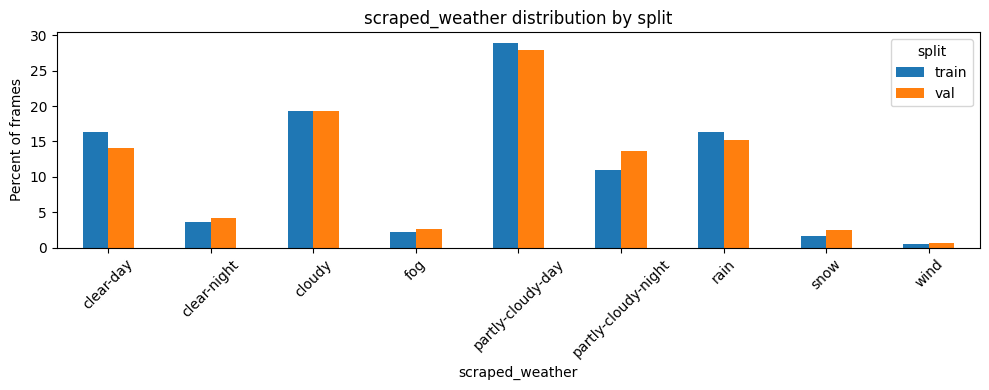

In [16]:
compare_distribution(df, 'scraped_weather')


road_type,arterial-rural,arterial-urban,city,highway,smaller-rural
split,,,,,
train,9.74,24.33,50.16,10.71,5.06
val,10.87,22.73,49.45,11.71,5.25


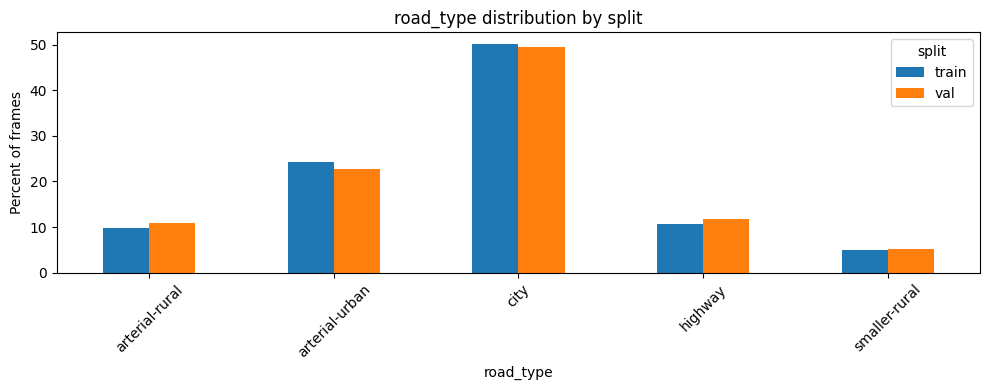

In [17]:
compare_distribution(df, 'road_type')


time_of_day,day,night,twilight
split,,,
train,77.58,19.09,3.33
val,75.21,20.78,4.00


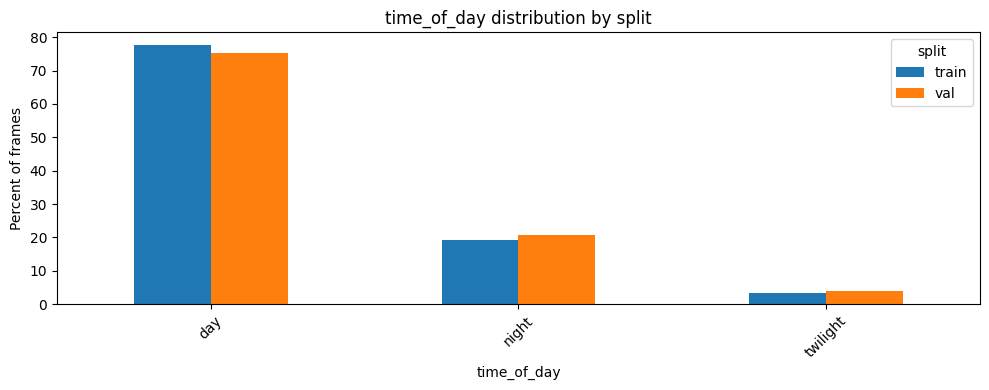

In [18]:
compare_distribution(df, 'time_of_day')
